# Quant Strategy Research

This notebook presents a reproducible research workflow for two transparent baseline strategies: time-series momentum and mean reversion. The goal is not to prove that either strategy is universally profitable, but to evaluate them carefully under explicit assumptions using the package code in `quant_research`.

## 1. Research Question

The central question is whether simple, transparent trend-following and mean-reversion rules produce economically meaningful results on a small diversified liquid universe once realistic frictions, out-of-sample evaluation, regime diagnostics, and basic statistical checks are included.

This is deliberately framed as descriptive research rather than a search for a final deployable strategy.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from quant_research.backtest import TradingAssumptions, run_vectorized_backtest
from quant_research.data import download_daily_ohlcv, simple_returns
from quant_research.metrics import (
    annualized_return,
    annualized_volatility,
    drawdown_series,
    maximum_drawdown,
    rolling_correlation,
    rolling_cumulative_return,
    rolling_sharpe_ratio,
    rolling_volatility,
    running_equity_curve,
    sharpe_ratio,
)
from quant_research.signals import mean_reversion_signal, time_series_momentum_signal
from quant_research.statistics import (
    bootstrap_sharpe_confidence_interval,
    distribution_diagnostics,
    mean_return_confidence_interval,
    mean_return_t_statistic,
    return_autocorrelation,
)
from quant_research.validation import (
    classify_volatility_regimes,
    chronological_train_test_split,
    evaluate_parameter_grid,
    performance_by_regime,
    stability_analysis,
    transaction_cost_sensitivity,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

UNIVERSE = ["SPY", "QQQ", "TLT", "GLD"]
START = "2010-01-01"
END = None
USE_CACHE = True

MOMENTUM_LOOKBACK = 126
MOMENTUM_NEUTRAL_BAND = 0.0
MEAN_REVERSION_LOOKBACK = 20
ENTRY_THRESHOLD = 1.5
EXIT_THRESHOLD = 0.5
MEAN_REVERSION_INPUT = "price"

TRANSACTION_COST_BPS = 5.0
PERIODS_PER_YEAR = 252
RISK_FREE_RATE = 0.0
INITIAL_CAPITAL = 1.0
LOOKBACK_GRID = [21, 42, 63, 126, 189, 252]
COST_GRID = [0.0, 1.0, 5.0, 10.0, 20.0]

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assumptions = TradingAssumptions(
    initial_capital=INITIAL_CAPITAL,
    periods_per_year=PERIODS_PER_YEAR,
    risk_free_rate=RISK_FREE_RATE,
    transaction_cost_bps_per_unit_turnover=TRANSACTION_COST_BPS,
    position_lag=1,
)


In [2]:
def build_price_panel(symbols: list[str]) -> pd.DataFrame:
    frames = download_daily_ohlcv(
        symbols,
        start=START,
        end=END,
        use_cache=USE_CACHE,
        cache_format="csv",
    )
    adjusted_close = {
        symbol: frame["adjusted_close"].rename(symbol)
        for symbol, frame in frames.items()
    }
    panel = pd.concat(adjusted_close.values(), axis=1, join="inner").sort_index()
    if panel.empty:
        raise ValueError("No overlapping adjusted-close history was available for the selected symbols.")
    return panel


def asset_return_panel(prices: pd.DataFrame) -> pd.DataFrame:
    returns = simple_returns(prices).dropna(how="any")
    if returns.empty:
        raise ValueError("Asset return panel is empty after return calculation.")
    return returns


def strategy_portfolio_returns(
    prices: pd.DataFrame,
    *,
    strategy_name: str,
    transaction_cost_bps: float,
    momentum_lookback: int = MOMENTUM_LOOKBACK,
    momentum_neutral_band: float = MOMENTUM_NEUTRAL_BAND,
    mean_reversion_lookback: int = MEAN_REVERSION_LOOKBACK,
    entry_threshold: float = ENTRY_THRESHOLD,
    exit_threshold: float = EXIT_THRESHOLD,
    mean_reversion_input: str = MEAN_REVERSION_INPUT,
) -> tuple[pd.Series, pd.Series]:
    returns = asset_return_panel(prices)
    config = TradingAssumptions(
        initial_capital=INITIAL_CAPITAL,
        periods_per_year=PERIODS_PER_YEAR,
        risk_free_rate=RISK_FREE_RATE,
        transaction_cost_bps_per_unit_turnover=transaction_cost_bps,
        position_lag=1,
    )
    net_by_asset: dict[str, pd.Series] = {}
    turnover_by_asset: dict[str, pd.Series] = {}

    for symbol in prices.columns:
        if strategy_name == "momentum":
            signal = time_series_momentum_signal(
                prices[symbol],
                lookback=momentum_lookback,
                neutral_band=momentum_neutral_band,
            )
        elif strategy_name == "mean_reversion":
            signal = mean_reversion_signal(
                prices[symbol],
                lookback=mean_reversion_lookback,
                entry_threshold=entry_threshold,
                exit_threshold=exit_threshold,
                signal_input=mean_reversion_input,
            )
        else:
            raise ValueError(f"Unsupported strategy_name: {strategy_name}.")

        target_positions = signal.target_positions.reindex(returns.index).fillna(0.0)
        result = run_vectorized_backtest(
            returns[symbol],
            target_positions,
            assumptions=config,
        )
        net_by_asset[symbol] = result.net_returns
        turnover_by_asset[symbol] = result.turnover

    portfolio_returns = pd.DataFrame(net_by_asset).mean(axis=1)
    average_turnover = pd.DataFrame(turnover_by_asset).mean(axis=1)
    return portfolio_returns, average_turnover


def summarize_returns(returns: pd.Series, turnover: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "annual_return": annualized_return(returns, periods_per_year=PERIODS_PER_YEAR),
            "annual_volatility": annualized_volatility(returns, periods_per_year=PERIODS_PER_YEAR),
            "sharpe": sharpe_ratio(
                returns,
                periods_per_year=PERIODS_PER_YEAR,
                risk_free_rate=RISK_FREE_RATE,
            ),
            "max_drawdown": maximum_drawdown(returns),
            "average_turnover": float(turnover.mean()),
            "total_turnover": float(turnover.sum()),
        }
    )


## 2. Data

The analysis uses adjusted daily prices from `yfinance` through the package data layer. The starting universe is a small diversified liquid set:

- `SPY`: broad US equities
- `QQQ`: growth / Nasdaq-heavy equities
- `TLT`: long-duration US Treasuries
- `GLD`: gold

This is not intended to be a complete investable universe. It is a compact research set that provides visibly different market behaviors.

In [3]:
prices = build_price_panel(UNIVERSE)
returns = asset_return_panel(prices)
prices.tail()

,SPY,QQQ,TLT,GLD
date,,,,
2026-08-04,771.330017,723.849976,82.820000,374.160004
2026-08-05,769.789978,717.299988,83.000000,389.640015
2026-08-06,768.559998,714.650024,82.519997,389.670013
2026-08-07,773.260010,723.030029,82.760002,398.470001
2026-08-10,773.030029,720.869995,82.059998,402.540009


## 3. Methodology

All strategy logic is implemented in the package and reused here. Signals are generated asset by asset, then backtested through the same lagged execution convention:

- signal at time `t` does not earn the return already observed at `t`,
- positions are lagged by one period in the backtester,
- transaction costs are applied as basis points per unit of turnover,
- equal-weight averaging is used across assets for the baseline portfolio comparison.

This notebook intentionally avoids reimplementing core formulas inside notebook cells.

## 4. Momentum Hypothesis

The momentum hypothesis is that assets with positive trailing returns may continue trending, while assets with negative trailing returns may continue underperforming over the next horizon. This is a simple time-series momentum rule rather than a cross-sectional ranking model.

## 5. Mean-Reversion Hypothesis

The mean-reversion hypothesis is that sufficiently extreme moves away from a recent reference level may partially reverse. The implementation uses rolling z-scores and symmetric entry/exit thresholds. This is descriptive and intentionally simple.

## 6. Backtesting Assumptions

- Daily data frequency
- One-period execution lag to avoid look-ahead bias
- Transaction cost assumption of 5 bps per unit turnover in the base case
- Equal-weight aggregation across assets in the baseline comparison
- No market-impact model
- No leverage beyond the explicit long/short exposure implicit in each strategy signal

In [4]:
momentum_returns, momentum_turnover = strategy_portfolio_returns(
    prices,
    strategy_name="momentum",
    transaction_cost_bps=TRANSACTION_COST_BPS,
)
mean_reversion_returns, mean_reversion_turnover = strategy_portfolio_returns(
    prices,
    strategy_name="mean_reversion",
    transaction_cost_bps=TRANSACTION_COST_BPS,
)
buy_and_hold_returns = returns.mean(axis=1)

summary_table = pd.DataFrame(
    {
        "Momentum": summarize_returns(momentum_returns, momentum_turnover),
        "Mean Reversion": summarize_returns(mean_reversion_returns, mean_reversion_turnover),
        "Buy-and-Hold": summarize_returns(buy_and_hold_returns, pd.Series(0.0, index=buy_and_hold_returns.index)),
    }
).T
summary_table

,annual_return,annual_volatility,sharpe,max_drawdown,average_turnover,total_turnover
Momentum,0.041836,0.104686,0.443922,-0.176770,0.056421,235.5
Mean Reversion,-0.020108,0.089962,-0.180847,-0.315942,0.116794,487.5
Buy-and-Hold,0.118757,0.105911,1.112746,-0.251545,0.000000,0.0


## 7. Performance Metrics

The package metrics layer reports annual return, annual volatility, Sharpe, max drawdown, and turnover. At this stage the purpose is not to find a winner mechanically, but to understand whether each strategy's return path looks economically plausible once costs and turnover are visible.

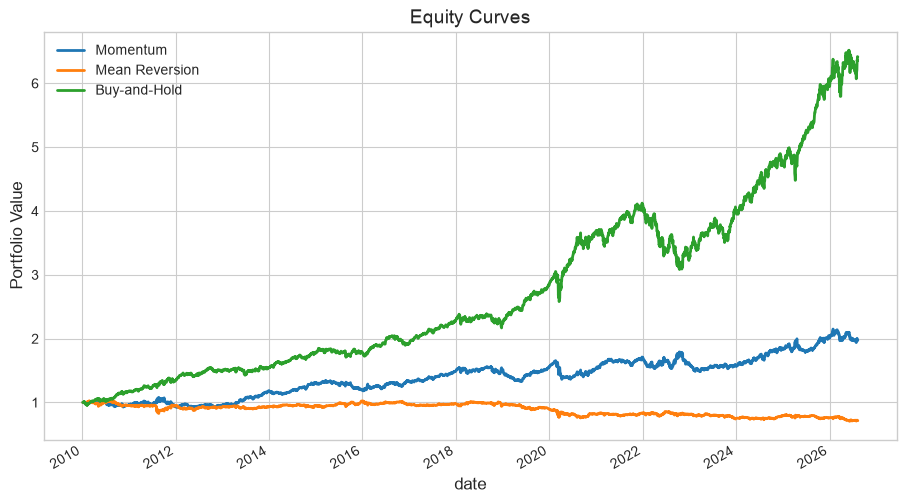

In [5]:
equity = pd.DataFrame(
    {
        "Momentum": running_equity_curve(momentum_returns, starting_value=INITIAL_CAPITAL),
        "Mean Reversion": running_equity_curve(mean_reversion_returns, starting_value=INITIAL_CAPITAL),
        "Buy-and-Hold": running_equity_curve(buy_and_hold_returns, starting_value=INITIAL_CAPITAL),
    }
)

ax = equity.plot(title="Equity Curves", linewidth=2)
ax.set_ylabel("Portfolio Value")
plt.show()

## 8. Transaction-Cost Sensitivity

A strategy that trades frequently can degrade materially once even modest execution costs are applied. The point of this exercise is not to estimate a perfect implementation shortfall model, but to see whether headline performance survives basic friction assumptions.

In [6]:
def cost_sensitivity(strategy_name: str) -> pd.DataFrame:
    def evaluator(cost_bps: float) -> dict[str, float]:
        strategy_returns, turnover = strategy_portfolio_returns(
            prices,
            strategy_name=strategy_name,
            transaction_cost_bps=cost_bps,
        )
        return {
            "net_annual_return": annualized_return(strategy_returns, periods_per_year=PERIODS_PER_YEAR),
            "sharpe": sharpe_ratio(
                strategy_returns,
                periods_per_year=PERIODS_PER_YEAR,
                risk_free_rate=RISK_FREE_RATE,
            ),
            "max_drawdown": maximum_drawdown(strategy_returns),
            "total_turnover": float(turnover.sum()),
        }
    
    return transaction_cost_sensitivity(COST_GRID, evaluator)


momentum_costs = cost_sensitivity("momentum")
mean_reversion_costs = cost_sensitivity("mean_reversion")

display(momentum_costs)
display(mean_reversion_costs)

,transaction_cost_bps,net_annual_return,sharpe,max_drawdown,total_turnover
0,0.0,0.049273,0.512051,-0.174469,235.5
1,1.0,0.047781,0.498427,-0.174930,235.5
2,5.0,0.041836,0.443922,-0.176770,235.5
3,10.0,0.034450,0.375793,-0.179751,235.5
4,20.0,0.019829,0.239662,-0.194429,235.5


,transaction_cost_bps,net_annual_return,sharpe,max_drawdown,total_turnover
0,0.0,-0.005575,-0.017277,-0.231526,487.5
1,1.0,-0.008499,-0.050009,-0.235113,487.5
2,5.0,-0.020108,-0.180847,-0.315942,487.5
3,10.0,-0.034432,-0.344115,-0.458517,487.5
4,20.0,-0.062462,-0.669243,-0.665589,487.5


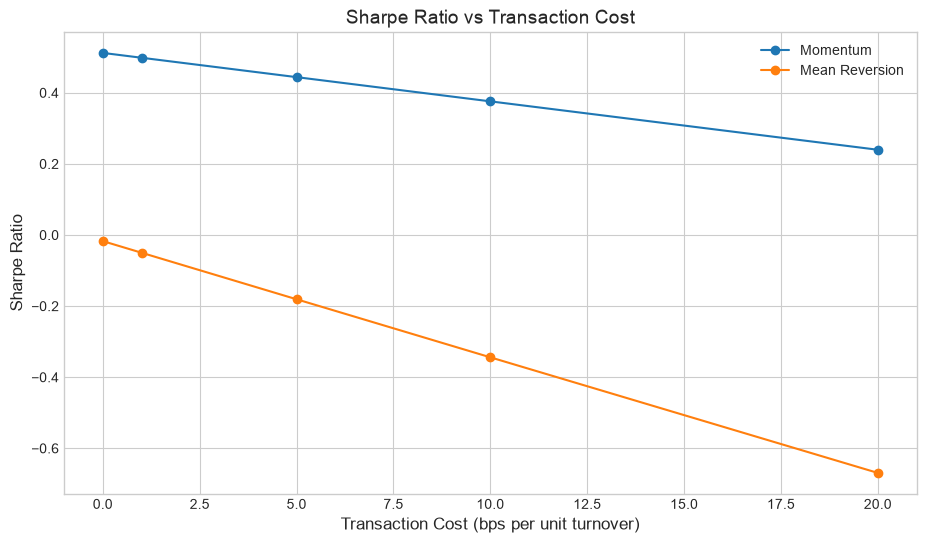

In [7]:
fig, ax = plt.subplots()
ax.plot(momentum_costs["transaction_cost_bps"], momentum_costs["sharpe"], marker="o", label="Momentum")
ax.plot(mean_reversion_costs["transaction_cost_bps"], mean_reversion_costs["sharpe"], marker="o", label="Mean Reversion")
ax.set_title("Sharpe Ratio vs Transaction Cost")
ax.set_xlabel("Transaction Cost (bps per unit turnover)")
ax.set_ylabel("Sharpe Ratio")
ax.legend()
plt.show()

If a strategy's Sharpe collapses quickly as costs rise, that is informative even when the gross signal looks reasonable. It suggests that turnover, implementation frictions, or both are central to whether the historical pattern is economically usable.

## 9. In-Sample vs Out-of-Sample Analysis

The momentum lookback is evaluated over a small set of reasonable windows without automatically selecting a winner. The emphasis is on whether out-of-sample performance is broadly stable or concentrated in one isolated historical choice.

In [8]:
def momentum_validation_record(params: dict[str, int]) -> dict[str, float]:
    candidate_returns, _ = strategy_portfolio_returns(
        prices,
        strategy_name="momentum",
        transaction_cost_bps=TRANSACTION_COST_BPS,
        momentum_lookback=params["lookback"],
    )
    split = chronological_train_test_split(candidate_returns, train_size=0.7)
    return {
        "in_sample_sharpe": sharpe_ratio(
            split.train,
            periods_per_year=PERIODS_PER_YEAR,
            risk_free_rate=RISK_FREE_RATE,
        ),
        "out_of_sample_sharpe": sharpe_ratio(
            split.test,
            periods_per_year=PERIODS_PER_YEAR,
            risk_free_rate=RISK_FREE_RATE,
        ),
    }


momentum_grid = evaluate_parameter_grid({"lookback": LOOKBACK_GRID}, momentum_validation_record)
momentum_stability = stability_analysis(
    momentum_grid,
    parameter_column="lookback",
    metric_column="out_of_sample_sharpe",
)
momentum_stability

,lookback,in_sample_sharpe,out_of_sample_sharpe,neighborhood_mean,neighborhood_std,neighborhood_count,stability_gap
0,21,-0.048439,-0.092249,0.256548,0.000000,1,0.348797
1,42,0.422982,0.256548,0.137998,0.230247,2,0.118550
2,63,0.157556,0.368245,0.316982,0.060434,2,0.051263
3,126,0.479522,0.377417,0.387050,0.018804,2,0.009633
4,189,0.252703,0.405854,0.378116,0.000700,2,0.027738
5,252,0.429843,0.378816,0.405854,0.000000,1,0.027038


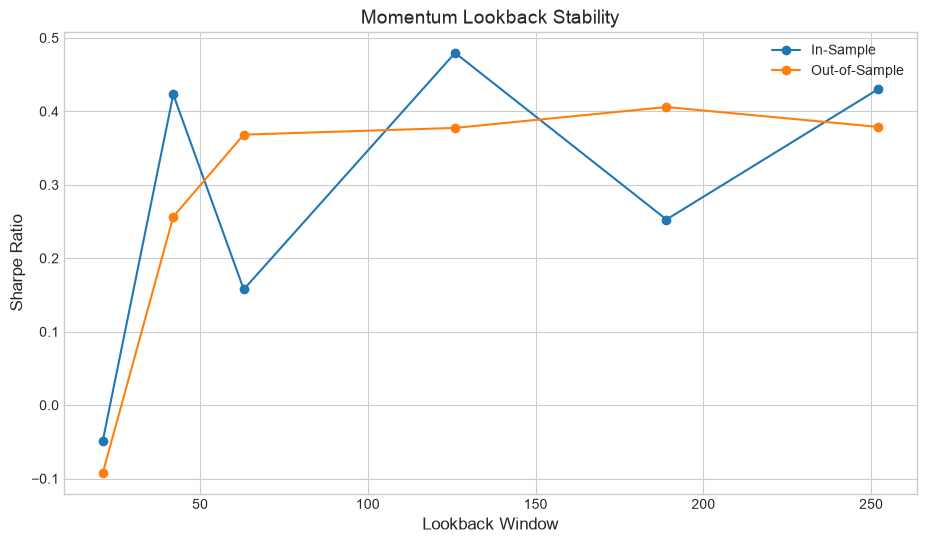

In [9]:
fig, ax = plt.subplots()
ax.plot(momentum_grid["lookback"], momentum_grid["in_sample_sharpe"], marker="o", label="In-Sample")
ax.plot(momentum_grid["lookback"], momentum_grid["out_of_sample_sharpe"], marker="o", label="Out-of-Sample")
ax.set_title("Momentum Lookback Stability")
ax.set_xlabel("Lookback Window")
ax.set_ylabel("Sharpe Ratio")
ax.legend()
plt.show()

Out-of-sample deterioration is not a failure of the notebook. It is part of the research result. If the best in-sample parameter does not generalize, that is evidence against overconfident model selection.

## 10. Rolling / Regime Behaviour

Rolling diagnostics show how unstable a strategy can be across time. The volatility-regime labels below are descriptive only: they are built from realized rolling volatility quantiles and should not be interpreted as a predictive regime model.

In [10]:
benchmark_vol_20 = rolling_volatility(buy_and_hold_returns, window=20, periods_per_year=PERIODS_PER_YEAR)
benchmark_vol_60 = rolling_volatility(buy_and_hold_returns, window=60, periods_per_year=PERIODS_PER_YEAR)
benchmark_vol_120 = rolling_volatility(buy_and_hold_returns, window=120, periods_per_year=PERIODS_PER_YEAR)

momentum_rolling_sharpe = rolling_sharpe_ratio(
    momentum_returns,
    window=60,
    periods_per_year=PERIODS_PER_YEAR,
    risk_free_rate=RISK_FREE_RATE,
)
mean_reversion_rolling_sharpe = rolling_sharpe_ratio(
    mean_reversion_returns,
    window=60,
    periods_per_year=PERIODS_PER_YEAR,
    risk_free_rate=RISK_FREE_RATE,
)

momentum_rolling_corr = rolling_correlation(momentum_returns, buy_and_hold_returns, window=60)
mean_reversion_rolling_corr = rolling_correlation(mean_reversion_returns, buy_and_hold_returns, window=60)
rolling_strategy_returns = pd.DataFrame(
    {
        "Momentum": rolling_cumulative_return(momentum_returns, window=20),
        "Mean Reversion": rolling_cumulative_return(mean_reversion_returns, window=20),
        "Buy-and-Hold": rolling_cumulative_return(buy_and_hold_returns, window=20),
    }
)

regimes = classify_volatility_regimes(benchmark_vol_60.dropna())
momentum_regime_summary = performance_by_regime(
    momentum_returns.reindex(regimes.index),
    regimes,
    periods_per_year=PERIODS_PER_YEAR,
    risk_free_rate=RISK_FREE_RATE,
)
mean_reversion_regime_summary = performance_by_regime(
    mean_reversion_returns.reindex(regimes.index),
    regimes,
    periods_per_year=PERIODS_PER_YEAR,
    risk_free_rate=RISK_FREE_RATE,
)

display(momentum_regime_summary)
display(mean_reversion_regime_summary)

,regime,observations,annual_return,sharpe_ratio,max_drawdown,hit_rate
0,low,1372,0.077365,1.053431,-0.089626,0.557749
1,medium,1371,0.116270,1.238412,-0.077843,0.549124
2,high,1372,-0.057994,-0.358917,-0.324053,0.504755


,regime,observations,annual_return,sharpe_ratio,max_drawdown,hit_rate
0,low,1372,-0.035215,-0.583402,-0.192570,0.472264
1,medium,1371,-0.011243,-0.094397,-0.175362,0.473118
2,high,1372,-0.014036,-0.059291,-0.188971,0.446415


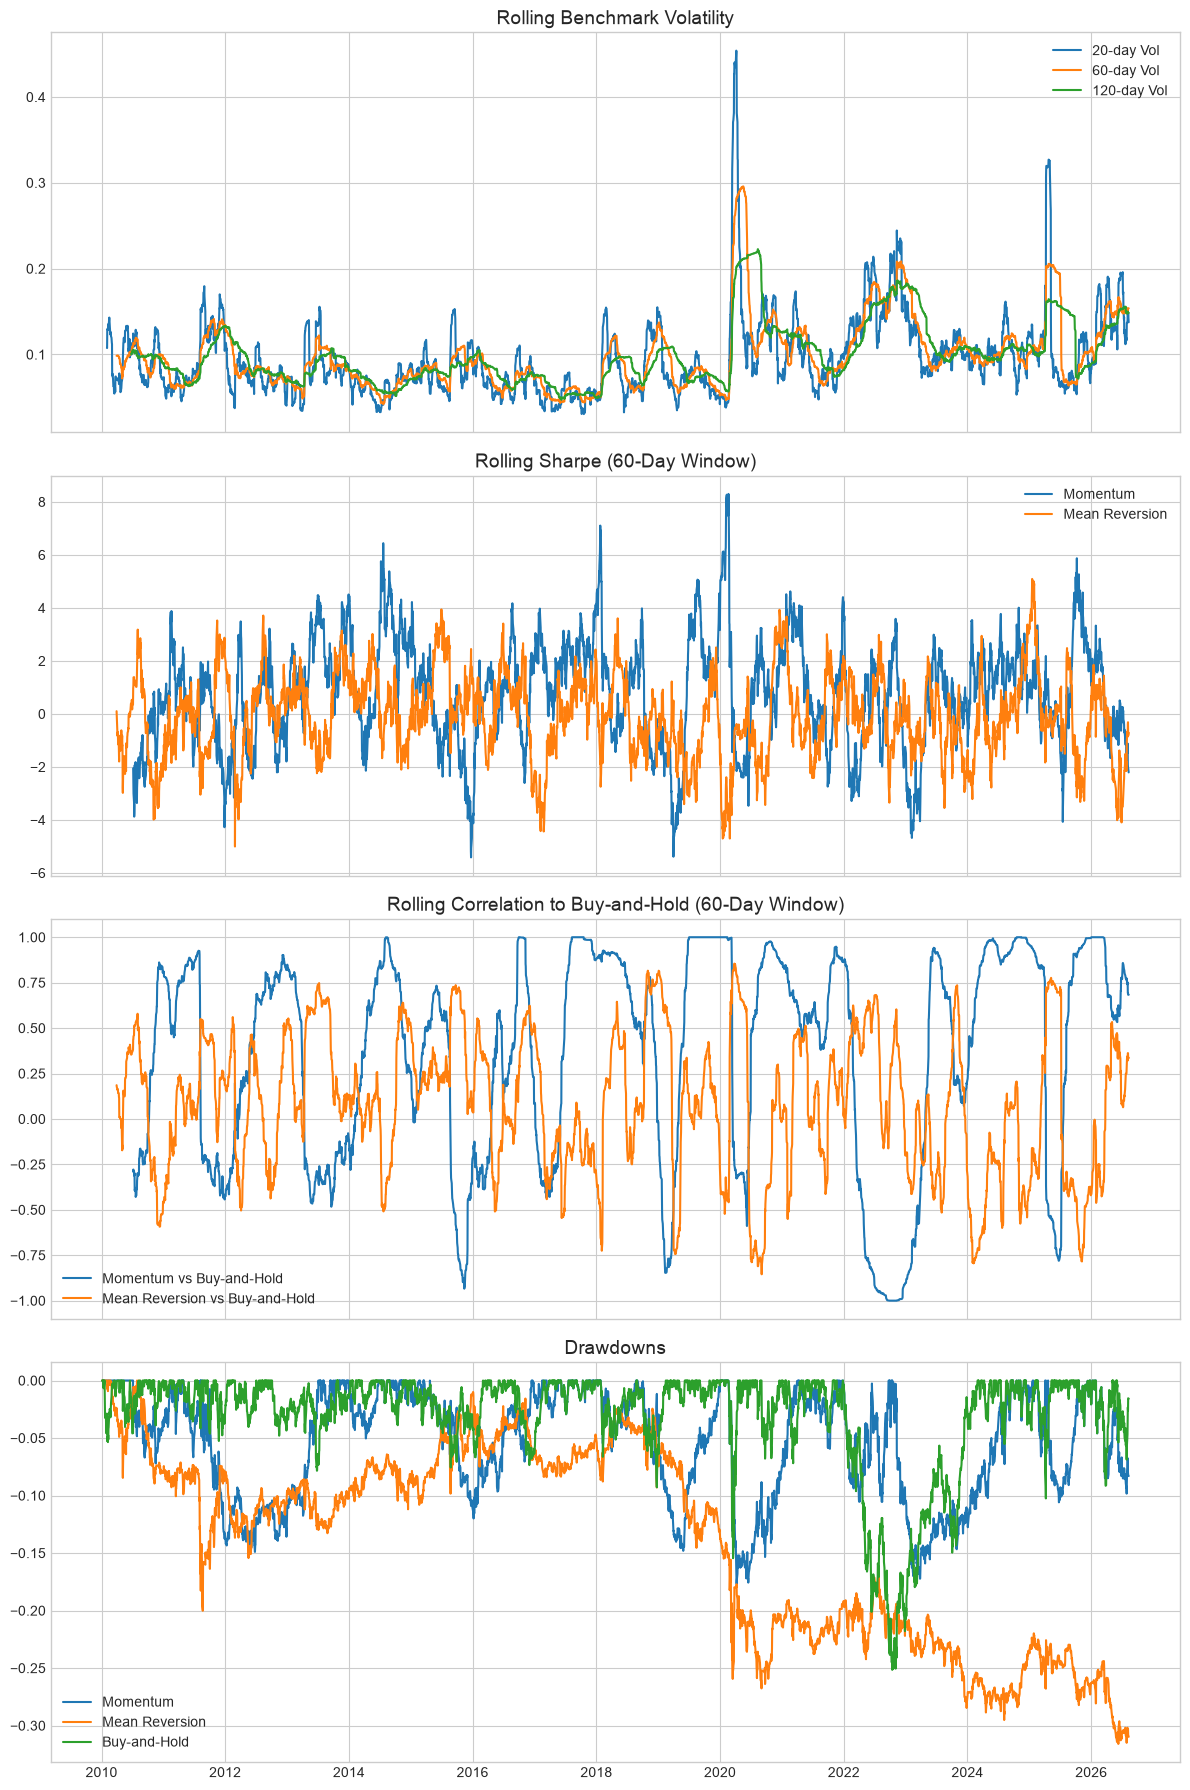

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)

axes[0].plot(benchmark_vol_20.index, benchmark_vol_20, label="20-day Vol")
axes[0].plot(benchmark_vol_60.index, benchmark_vol_60, label="60-day Vol")
axes[0].plot(benchmark_vol_120.index, benchmark_vol_120, label="120-day Vol")
axes[0].set_title("Rolling Benchmark Volatility")
axes[0].legend()

axes[1].plot(momentum_rolling_sharpe.index, momentum_rolling_sharpe, label="Momentum")
axes[1].plot(mean_reversion_rolling_sharpe.index, mean_reversion_rolling_sharpe, label="Mean Reversion")
axes[1].set_title("Rolling Sharpe (60-Day Window)")
axes[1].legend()

axes[2].plot(momentum_rolling_corr.index, momentum_rolling_corr, label="Momentum vs Buy-and-Hold")
axes[2].plot(mean_reversion_rolling_corr.index, mean_reversion_rolling_corr, label="Mean Reversion vs Buy-and-Hold")
axes[2].set_title("Rolling Correlation to Buy-and-Hold (60-Day Window)")
axes[2].legend()

axes[3].plot(drawdown_series(momentum_returns).index, drawdown_series(momentum_returns), label="Momentum")
axes[3].plot(drawdown_series(mean_reversion_returns).index, drawdown_series(mean_reversion_returns), label="Mean Reversion")
axes[3].plot(drawdown_series(buy_and_hold_returns).index, drawdown_series(buy_and_hold_returns), label="Buy-and-Hold")
axes[3].set_title("Drawdowns")
axes[3].legend()

fig.tight_layout()
plt.show()

## 11. Statistical Diagnostics

These diagnostics are intentionally presented with caution. Financial returns often violate IID assumptions through autocorrelation, volatility clustering, fat tails, and regime shifts. That means standard t-statistics and simple bootstrap intervals are only rough evidence, not proof.

In [12]:
momentum_stats = {
    "t_stat": mean_return_t_statistic(momentum_returns),
    "mean_ci": mean_return_confidence_interval(momentum_returns),
    "sharpe_ci": bootstrap_sharpe_confidence_interval(
        momentum_returns,
        periods_per_year=PERIODS_PER_YEAR,
        risk_free_rate=RISK_FREE_RATE,
        n_bootstrap=500,
    ),
    "autocorrelation": return_autocorrelation(momentum_returns, lags=(1, 5, 20)),
    "distribution": distribution_diagnostics(momentum_returns),
}
mean_reversion_stats = {
    "t_stat": mean_return_t_statistic(mean_reversion_returns),
    "mean_ci": mean_return_confidence_interval(mean_reversion_returns),
    "sharpe_ci": bootstrap_sharpe_confidence_interval(
        mean_reversion_returns,
        periods_per_year=PERIODS_PER_YEAR,
        risk_free_rate=RISK_FREE_RATE,
        n_bootstrap=500,
    ),
    "autocorrelation": return_autocorrelation(mean_reversion_returns, lags=(1, 5, 20)),
    "distribution": distribution_diagnostics(mean_reversion_returns),
}

diagnostic_table = pd.DataFrame(
    {
        "Momentum": {
            "mean_t_stat": momentum_stats["t_stat"],
            "mean_ci_lower": momentum_stats["mean_ci"].lower,
            "mean_ci_upper": momentum_stats["mean_ci"].upper,
            "bootstrap_sharpe_lower": momentum_stats["sharpe_ci"].lower,
            "bootstrap_sharpe_upper": momentum_stats["sharpe_ci"].upper,
            "autocorr_lag_1": momentum_stats["autocorrelation"].loc[1],
            "autocorr_lag_5": momentum_stats["autocorrelation"].loc[5],
            "autocorr_lag_20": momentum_stats["autocorrelation"].loc[20],
            "skewness": momentum_stats["distribution"].skewness,
            "excess_kurtosis": momentum_stats["distribution"].excess_kurtosis,
        },
        "Mean Reversion": {
            "mean_t_stat": mean_reversion_stats["t_stat"],
            "mean_ci_lower": mean_reversion_stats["mean_ci"].lower,
            "mean_ci_upper": mean_reversion_stats["mean_ci"].upper,
            "bootstrap_sharpe_lower": mean_reversion_stats["sharpe_ci"].lower,
            "bootstrap_sharpe_upper": mean_reversion_stats["sharpe_ci"].upper,
            "autocorr_lag_1": mean_reversion_stats["autocorrelation"].loc[1],
            "autocorr_lag_5": mean_reversion_stats["autocorrelation"].loc[5],
            "autocorr_lag_20": mean_reversion_stats["autocorrelation"].loc[20],
            "skewness": mean_reversion_stats["distribution"].skewness,
            "excess_kurtosis": mean_reversion_stats["distribution"].excess_kurtosis,
        },
    }
).T
diagnostic_table

,mean_t_stat,mean_ci_lower,mean_ci_upper,bootstrap_sharpe_lower,bootstrap_sharpe_upper,autocorr_lag_1,autocorr_lag_5,autocorr_lag_20,skewness,excess_kurtosis
Momentum,1.806687,-0.000016,0.000385,-0.019277,0.925320,-0.064723,-0.048059,0.029040,-0.245264,9.602849
Mean Reversion,-0.736015,-0.000237,0.000107,-0.692962,0.256527,-0.138672,-0.005513,0.009617,0.270410,17.213085


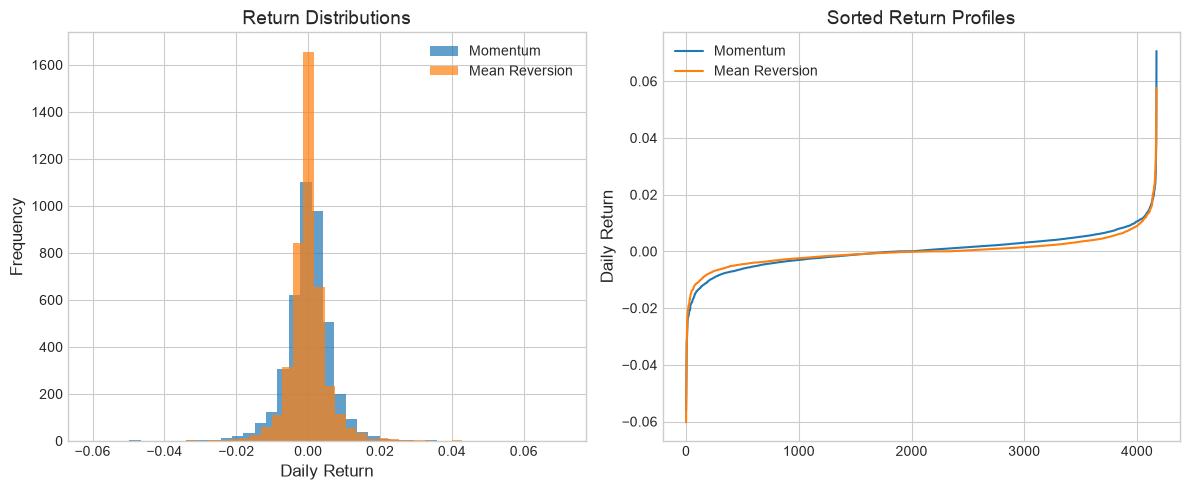

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(momentum_returns.dropna(), bins=40, alpha=0.7, label="Momentum")
axes[0].hist(mean_reversion_returns.dropna(), bins=40, alpha=0.7, label="Mean Reversion")
axes[0].set_title("Return Distributions")
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Frequency")
axes[0].legend()

pd.DataFrame(
    {
        "Momentum": momentum_returns.dropna().sort_values().reset_index(drop=True),
        "Mean Reversion": mean_reversion_returns.dropna().sort_values().reset_index(drop=True),
    }
).plot(ax=axes[1], title="Sorted Return Profiles")
axes[1].set_ylabel("Daily Return")

plt.tight_layout()
plt.show()

## 12. Limitations

- The universe is intentionally small and not exhaustive.
- `yfinance` is a convenient starting source, not an institutional data pipeline.
- Transaction costs are simplified to basis points per unit turnover.
- The strategies are intentionally transparent and therefore incomplete.
- Statistical inference is fragile when returns are autocorrelated, heteroskedastic, or regime-dependent.
- Descriptive volatility regimes are not predictive market-state forecasts.
- A backtest is not proof of future profitability.

Poor performance is also informative. If a simple idea fails once costs, turnover, or out-of-sample checks are introduced, that is evidence about the weakness of the hypothesis or the inadequacy of the implementation.

## 13. Conclusions and Next Research Questions

Several conclusions matter more than any single headline Sharpe ratio:

- whether performance survives transaction costs,
- whether it generalizes out of sample,
- whether it is stable across neighboring parameters,
- whether its behavior changes materially by volatility environment,
- whether the distribution and autocorrelation diagnostics suggest fragile assumptions.

Natural next steps:

1. Expand the asset universe while preserving data-quality controls.
2. Add more robust portfolio construction built on stable risk controls rather than unstable covariance inversion.
3. Add walk-forward validation and richer regime segmentation.
4. Compare daily and weekly implementations to test sensitivity to sampling frequency.
5. Replace convenience-data assumptions with stronger research data as the platform matures.

The main research takeaway is not that one simple strategy must be correct. It is that disciplined process, explicit assumptions, and honest diagnostics matter more than attractive raw backtest output.